Saving sss.avif to sss.avif


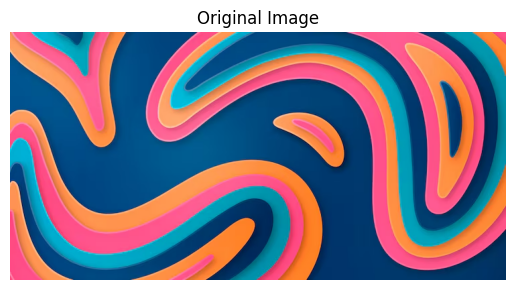

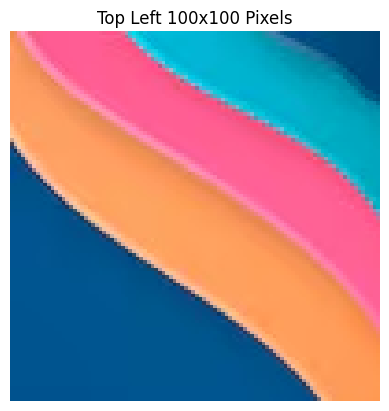

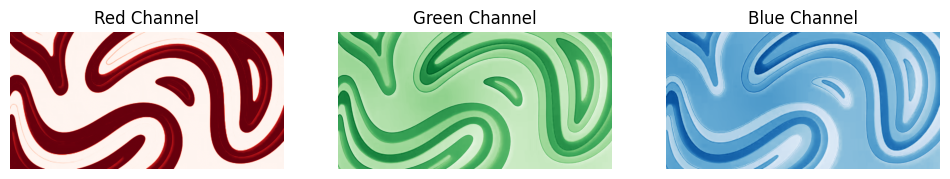

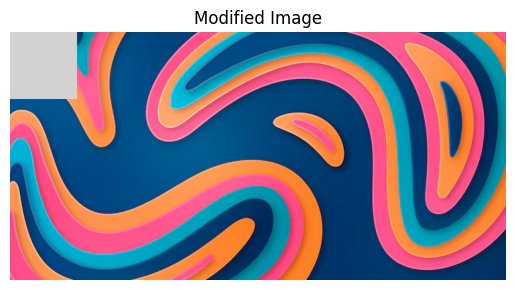

In [ ]:
 # Exercise 1

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload Image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read Image
img = Image.open(filename)
img_array = np.array(img)

# 1 Display Image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 2 Top Left 100x100 Pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

# 3 RGB Channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

# 4 Modify Top 100x100 Pixels
modified = img_array.copy()
modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

Saving cameraman.png to cameraman.png


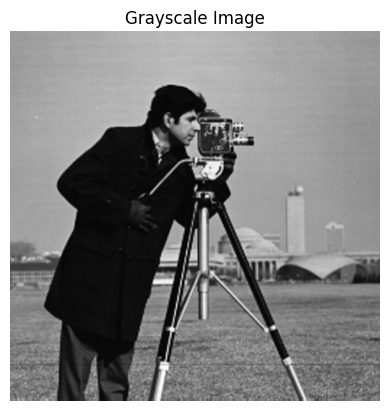

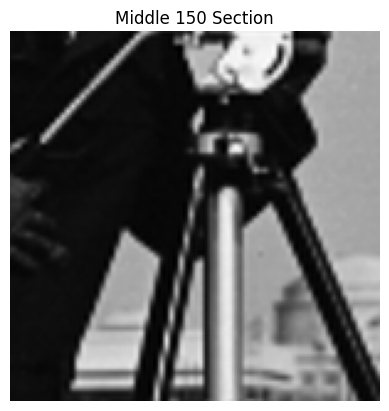

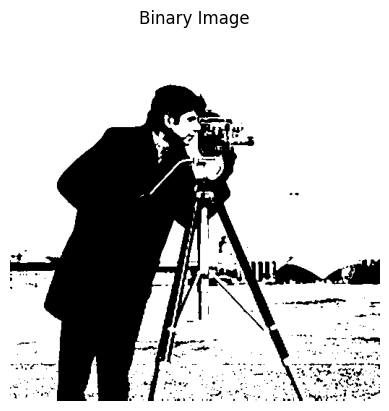

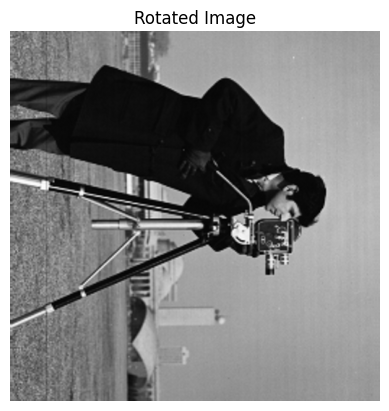

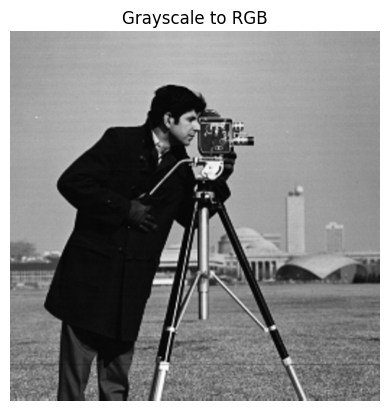

In [ ]:
# Exercise 2

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload Image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load Grayscale Image
img = Image.open(filename).convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 1 Extract Middle 150 Pixels
h, w = img_array.shape

middle = img_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150 Section")
plt.axis("off")
plt.show()

# 2 Apply Threshold
binary = img_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

# 3 Rotate 90 Degrees Clockwise
rotated = img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

# 4 Convert Grayscale to RGB
rgb = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale to RGB")
plt.axis("off")
plt.show()

Saving lena_gray.gif to lena_gray (2).gif


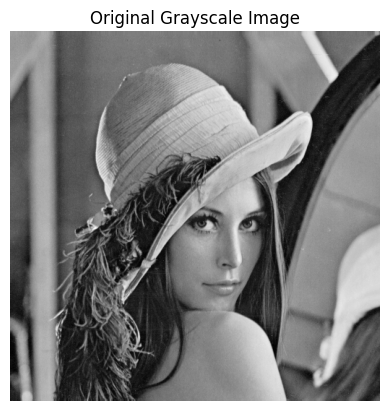

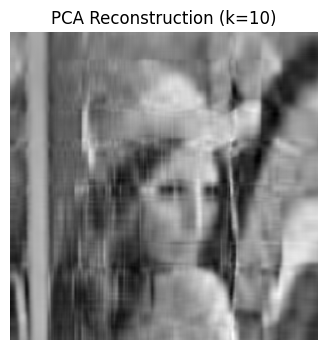

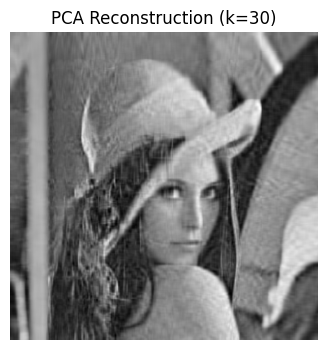

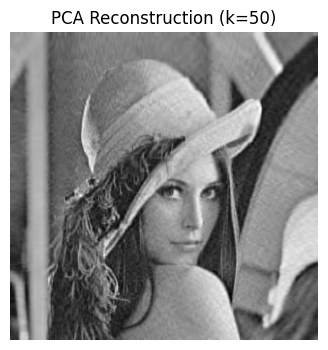

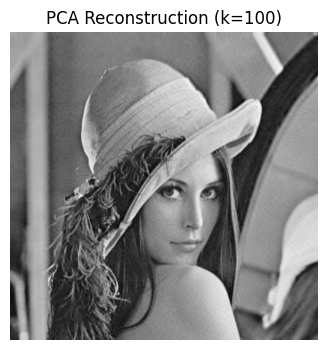

In [ ]:
# Exercise 3 - PCA Image Compression

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload Image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load Image and convert to Grayscale
img = Image.open(filename).convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# 1 Center the Data

X = img_array.astype(float)

mean = np.mean(X, axis=0)
X_centered = X - mean

# 2 Covariance Matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# 3 Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# 4 Sort Eigenvalues
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# # 5 Explained Variance Plot
# explained_variance = eigen_values / np.sum(eigen_values)

# cumulative_variance = np.cumsum(explained_variance)

# plt.plot(cumulative_variance)
# plt.title("Cumulative Explained Variance")
# plt.xlabel("Number of Components")
# plt.ylabel("Variance Explained")
# plt.show()

# 6 PCA Reconstruction
components = [10, 30, 50, 100]

for k in components:

    PCs = eigen_vectors[:, :k]

    compressed = np.dot(X_centered, PCs)

    reconstructed = np.dot(compressed, PCs.T) + mean

    plt.figure(figsize=(4,4))
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"PCA Reconstruction (k={k})")
    plt.axis("off")
    plt.show()